# Comparing Gradient Boosted Trees on Unsafe Fishermen Behaviour Prediction

## Importing packages

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns

## Load and Preprocess the Data

In [3]:
df = pd.read_csv('data/data-master.csv', sep=';')

print(f"The shape of the dataset: {df.shape}")
df.head(5)

The shape of the dataset: (1641, 79)


,Respondent_ID,Age,Fishing Experience,Province,Beach,Fishing Role,Experience as Head of Communities,Boat Type,Fishing Duration,Usage of LIK,...,Number of LIK Combination,Usage Persistance,Usage Duration,Frequency of Usage (min) (in month),Frequency of Usage (max) (in month),Average Frequency of Usage (in month),"Number of Prediction Made (the last month, except tsunami)","Disaster Happen (the last month, except tsunami)",Perceived of Accuracy,Action Anticipation (Respon based on LIK codes)
0,1,20,2,1,1,1,0,4,1,1,...,4,1,15,30.0,30.0,30,1,1.0,100,Ts-1: Be careful
1,1,20,2,1,1,1,0,4,1,1,...,4,1,15,30.0,30.0,30,1,1.0,100,Ts-2: Run to high place
2,1,20,2,1,1,1,0,4,1,1,...,4,1,15,30.0,30.0,30,1,1.0,100,Ts-4: Run to high place
3,1,20,2,1,1,1,0,4,1,1,...,4,1,15,30.0,30.0,30,1,1.0,100,Ts-5: Move away from beach
4,1,20,2,1,1,1,0,4,1,1,...,1,1,1,2.0,5.0,"3,5",15,11.0,"73,33333333",Wv-1: Adjust fishing equipment


In [4]:
# Filtering selected data rows

def filter_and_clean_df(df, disaster_code, target_col, demographic_cols_to_keep):
  df_filtered_rows = df[df['Action Anticipation (Respon based on LIK codes)'].str.startswith(disaster_code)].copy()
  all_current_cols = df_filtered_rows.columns.tolist()

  disaster_specific_cols = [c for c in all_current_cols if c.startswith(disaster_code)]

  cols_to_preserve_set = set(disaster_specific_cols + [target_col] + demographic_cols_to_keep)

  cols_to_drop_final = [col for col in all_current_cols if col not in cols_to_preserve_set]

  df_filtered_rows.drop(columns=cols_to_drop_final, inplace=True)

  df_filtered_rows[target_col] = df_filtered_rows[target_col].astype(str).str.strip()

  return df_filtered_rows

In [5]:
cols_to_drop = [c for c in df.columns.tolist() if not c.startswith('Wn')]

demographic_cols = [
    'Age', 'Fishing Experience', 'Province', 'Fishing Role', 'Experience as Head of Communities', 'Fishing Duration',
    'Number of Experience with Disaster', 'Level of Interaction with Disaster', 'Number of LIK Combination',
    'Usage Duration', 'Frequency of Usage (min) (in month)', 'Frequency of Usage (max) (in month)',
    'Average Frequency of Usage (in month)'
]

df = filter_and_clean_df(df, 'Wn', 'Action Anticipation (Respon based on LIK codes)', demographic_cols)

print(f"Shape of dataframe: {df.shape}")

df.head()

Shape of dataframe: (669, 31)


,Age,Fishing Experience,Province,Fishing Role,Experience as Head of Communities,Fishing Duration,Number of Experience with Disaster,Level of Interaction with Disaster,Wn-1,Wn-10,...,Wn-6,Wn-7,Wn-8,Wn-9,Number of LIK Combination,Usage Duration,Frequency of Usage (min) (in month),Frequency of Usage (max) (in month),Average Frequency of Usage (in month),Action Anticipation (Respon based on LIK codes)
8,23,3,1,1,0,1,1,2,0,0,...,0,0,0,0,2,3,3.0,4.0,"3,5",Wn-3: Adjust fishing time
9,23,3,1,1,0,1,1,2,0,0,...,0,0,0,0,2,3,3.0,4.0,"3,5",Wn-4: Adjust fishing time
10,24,2,1,1,0,1,2,5,0,0,...,0,0,0,0,3,2,16.0,20.0,18,Wn-3: Adjust fishing time
11,24,2,1,1,0,1,2,5,0,0,...,0,0,1,0,3,2,16.0,20.0,18,Wn-8: Repair boat
12,24,2,1,1,0,1,2,5,0,0,...,0,0,0,0,3,2,16.0,20.0,18,Wn-11: Be careful


In [6]:
# Preprocessing data types
unique_action_responses = df['Action Anticipation (Respon based on LIK codes)'].apply(lambda x: x.split(':')[-1].strip()).unique()
print("Unique Action Anticipation Responses:")
for response in unique_action_responses:
    print(f"- {response}")

Unique Action Anticipation Responses:
- Adjust fishing time
- Repair boat
- Be careful
- Stay alert/retrieve fishing gear
- No action
- Move away from beach
- siaga ditempat
- Stop fishing activities
- Adjust fishing equipment


In [7]:
def map_action_level(text):
    text = str(text).lower().strip()

    if any(keyword in text for keyword in [
        'move away',
        'stop fishing',
        'retrieve',
        'adjust fishing time',
        'siaga',
        'alert',
        'adjust',
        'repair boat'
    ]):
        return 1

    return 0

In [8]:
df['Target_Action_Level'] = df['Action Anticipation (Respon based on LIK codes)'].apply(map_action_level)
df.drop(columns=['Action Anticipation (Respon based on LIK codes)'], inplace=True)

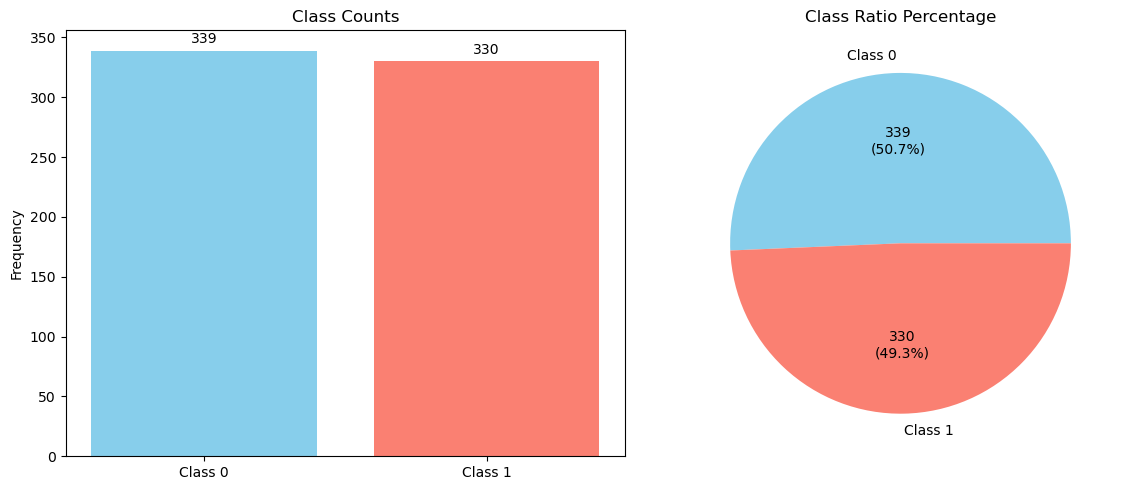

In [9]:
labels = list(df['Target_Action_Level'])
classes = sorted(list(set(labels)))
counts = [labels.count(c) for c in classes]
class_names = [f'Class {c}' for c in classes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Bar Chart
bars = ax1.bar(class_names, counts, color=['skyblue', 'salmon', 'lightgreen'])
ax1.bar_label(bars, padding=3)
ax1.set_title('Class Counts')
ax1.set_ylabel('Frequency')

# 2. Pie Chart with Raw Counts and Percentages
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{val}\n({pct:.1f}%)'
    return my_autopct

ax2.pie(counts, labels=class_names, autopct=make_autopct(counts), colors=['skyblue', 'salmon', 'lightgreen'])
ax2.set_title('Class Ratio Percentage')

plt.tight_layout()
plt.show()

In [10]:
# Making sure all the dtypes numeric
df['Average Frequency of Usage (in month)'] = df['Average Frequency of Usage (in month)'].astype(str).str.strip()
df['Average Frequency of Usage (in month)'] = pd.to_numeric(df['Average Frequency of Usage (in month)'].str.replace(',', '.'))
df['Average Frequency of Usage (in month)'] = pd.to_numeric(df['Average Frequency of Usage (in month)'])

df.info()

<class 'pandas.DataFrame'>
Index: 669 entries, 8 to 1640
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Age                                    669 non-null    int64  
 1   Fishing Experience                     669 non-null    int64  
 2   Province                               669 non-null    int64  
 3   Fishing Role                           669 non-null    int64  
 4   Experience as Head of Communities      669 non-null    int64  
 5   Fishing Duration                       669 non-null    int64  
 6   Number of Experience with Disaster     669 non-null    int64  
 7   Level of Interaction with Disaster     669 non-null    int64  
 8   Wn-1                                   669 non-null    int64  
 9   Wn-10                                  669 non-null    int64  
 10  Wn-11                                  669 non-null    int64  
 11  Wn-12                

In [11]:
# Save the processed data for modeling & shap analysis
df.to_csv('data/processed-modeling-data.csv', index=False)

## Prepare Dataset For Modeling

In [4]:
# Split the data
df = pd.read_csv('data/processed-modeling-data.csv')
X = df.drop(columns=['Target_Action_Level'])
y = df['Target_Action_Level']

X_train_20, X_test_20, y_train_20, y_test_20 = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_25, X_test_25, y_train_25, y_test_25 = train_test_split(X, y, test_size=0.25, random_state=42)
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
# Evaluation function
def evaluate_model(model, test_size, mean_score, std_score):
    
    if test_size == 0.2:
        X_train, X_test, y_train, y_test = X_train_20, X_test_20, y_train_20, y_test_20
    elif test_size == 0.25:
        X_train, X_test, y_train, y_test = X_train_25, X_test_25, y_train_25, y_test_25
    else:
        X_train, X_test, y_train, y_test = X_train_30, X_test_30, y_train_30, y_test_30
    
    y_pred = model.predict(X_test)

    print(f"F1-Score: {mean_score:.2f} (+/- {std_score:.3f})\n")
    
    print("--- Classification Report ---")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Action (0)', 'Actionable (1)'],
                yticklabels=['No Action (0)', 'Actionable (1)'])
    
    plt.title('Confusion Matrix: Disaster Response Prediction')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()

In [8]:
# Visualize ROC-AUC curve function

def plot_multimodel_roc(model_dict, title="ROC Curve Analysis", save_path=None):

    plt.figure(figsize=(8, 7), dpi=300)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for i, (label, (model, X_test, y_test)) in enumerate(model_dict.items()):
        y_prob = model.predict_proba(X_test)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2.5, color=colors[i % len(colors)],
                 label=f'{label} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', alpha=0.5)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='500')
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='500')
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.legend(loc="lower right", fontsize=10, frameon=True, shadow=False)
    plt.grid(visible=True, linestyle=':', alpha=0.5)
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    plt.show()

## XGBoost

### Training

In [9]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

def train_and_tune_xgb(test_size):
    
    if test_size == 0.2:
        X_train, X_test, y_train = X_train_20, X_test_20, y_train_20
    elif test_size == 0.25:
        X_train, X_test, y_train = X_train_25, X_test_25, y_train_25
    else:
        X_train, X_test, y_train = X_train_30, X_test_30, y_train_30

    train_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    param_grid = {
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 150, 200, 250],
        'subsample': [0.8, 1.0]
    }
    
    xgb_base = XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        objective='binary:logistic'
    )
    
    grid_search = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        cv=5,              
        scoring='f1_macro',
        verbose=1,
        n_jobs=-1
    )
    
    grid_search.fit(
        X_train, 
        y_train,
        sample_weight=train_sample_weights,
    )

    print(f"===XGBOOST TUNING RESULT FOR SPLIT {test_size*100}:{(1-test_size)*100}===")
    print(f"Best Parameters: {grid_search.best_params_}\n")
    
    return grid_search.best_estimator_, grid_search.best_score_, grid_search.cv_results_['std_test_score'][grid_search.best_index_]

xgb_20, mean_score_xgb_20, std_score_xgb_20 = train_and_tune_xgb(test_size=0.2)
xgb_25, mean_score_xgb_25, std_score_xgb_25= train_and_tune_xgb(test_size=0.25)
xgb_30, mean_score_xgb_30, std_score_xgb_30 = train_and_tune_xgb(test_size=0.30)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
===XGBOOST TUNING RESULT FOR SPLIT 20.0:80.0===
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}

Fitting 5 folds for each of 96 candidates, totalling 480 fits
===XGBOOST TUNING RESULT FOR SPLIT 25.0:75.0===
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.8}

Fitting 5 folds for each of 96 candidates, totalling 480 fits
===XGBOOST TUNING RESULT FOR SPLIT 30.0:70.0===
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}



### Confusion Matrix and Classification Report

F1-Score: 0.76 (+/- 0.004)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.77      0.81        71
           1       0.77      0.86      0.81        63

    accuracy                           0.81       134
   macro avg       0.82      0.82      0.81       134
weighted avg       0.82      0.81      0.81       134



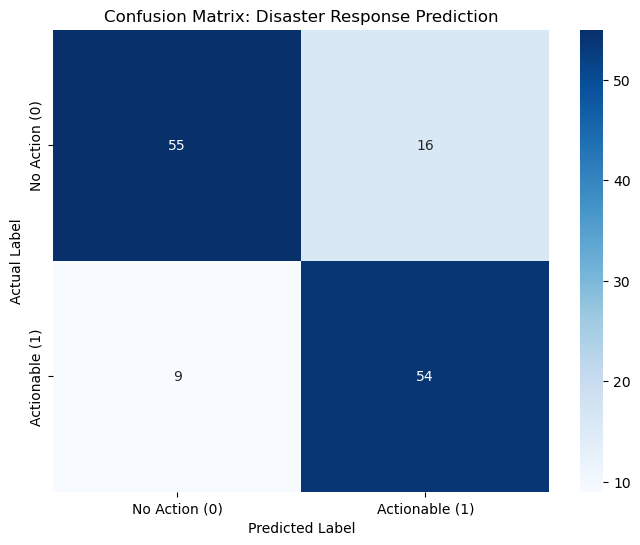

In [10]:
# Evaluate the 20 split
evaluate_model(xgb_20, test_size=0.2, mean_score=mean_score_xgb_20, std_score=std_score_xgb_20)

F1-Score: 0.76 (+/- 0.02)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.73      0.77        89
           1       0.73      0.82      0.77        79

    accuracy                           0.77       168
   macro avg       0.78      0.78      0.77       168
weighted avg       0.78      0.77      0.77       168



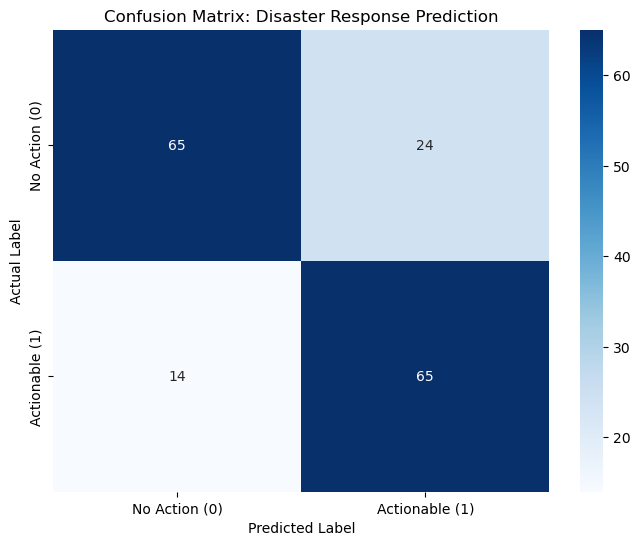

In [47]:
# Evaluate the 25 split
evaluate_model(xgb_25, test_size=0.25, mean_score=mean_score_xgb_25, std_score=std_score_xgb_25)

F1-Score: 0.75 (+/- 0.04)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.70      0.76       108
           1       0.71      0.84      0.77        93

    accuracy                           0.77       201
   macro avg       0.77      0.77      0.77       201
weighted avg       0.78      0.77      0.77       201



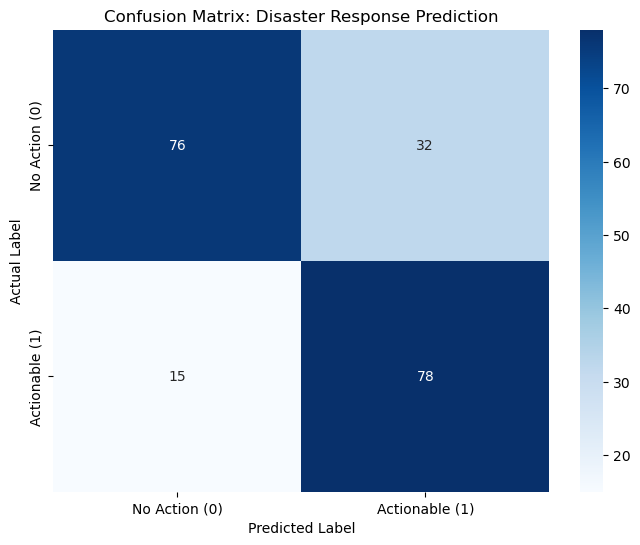

In [48]:
# Evaluate the 30 split
evaluate_model(xgb_30, test_size=0.3, mean_score=mean_score_xgb_30, std_score=std_score_xgb_30)

### ROC-AUC Curve across splits

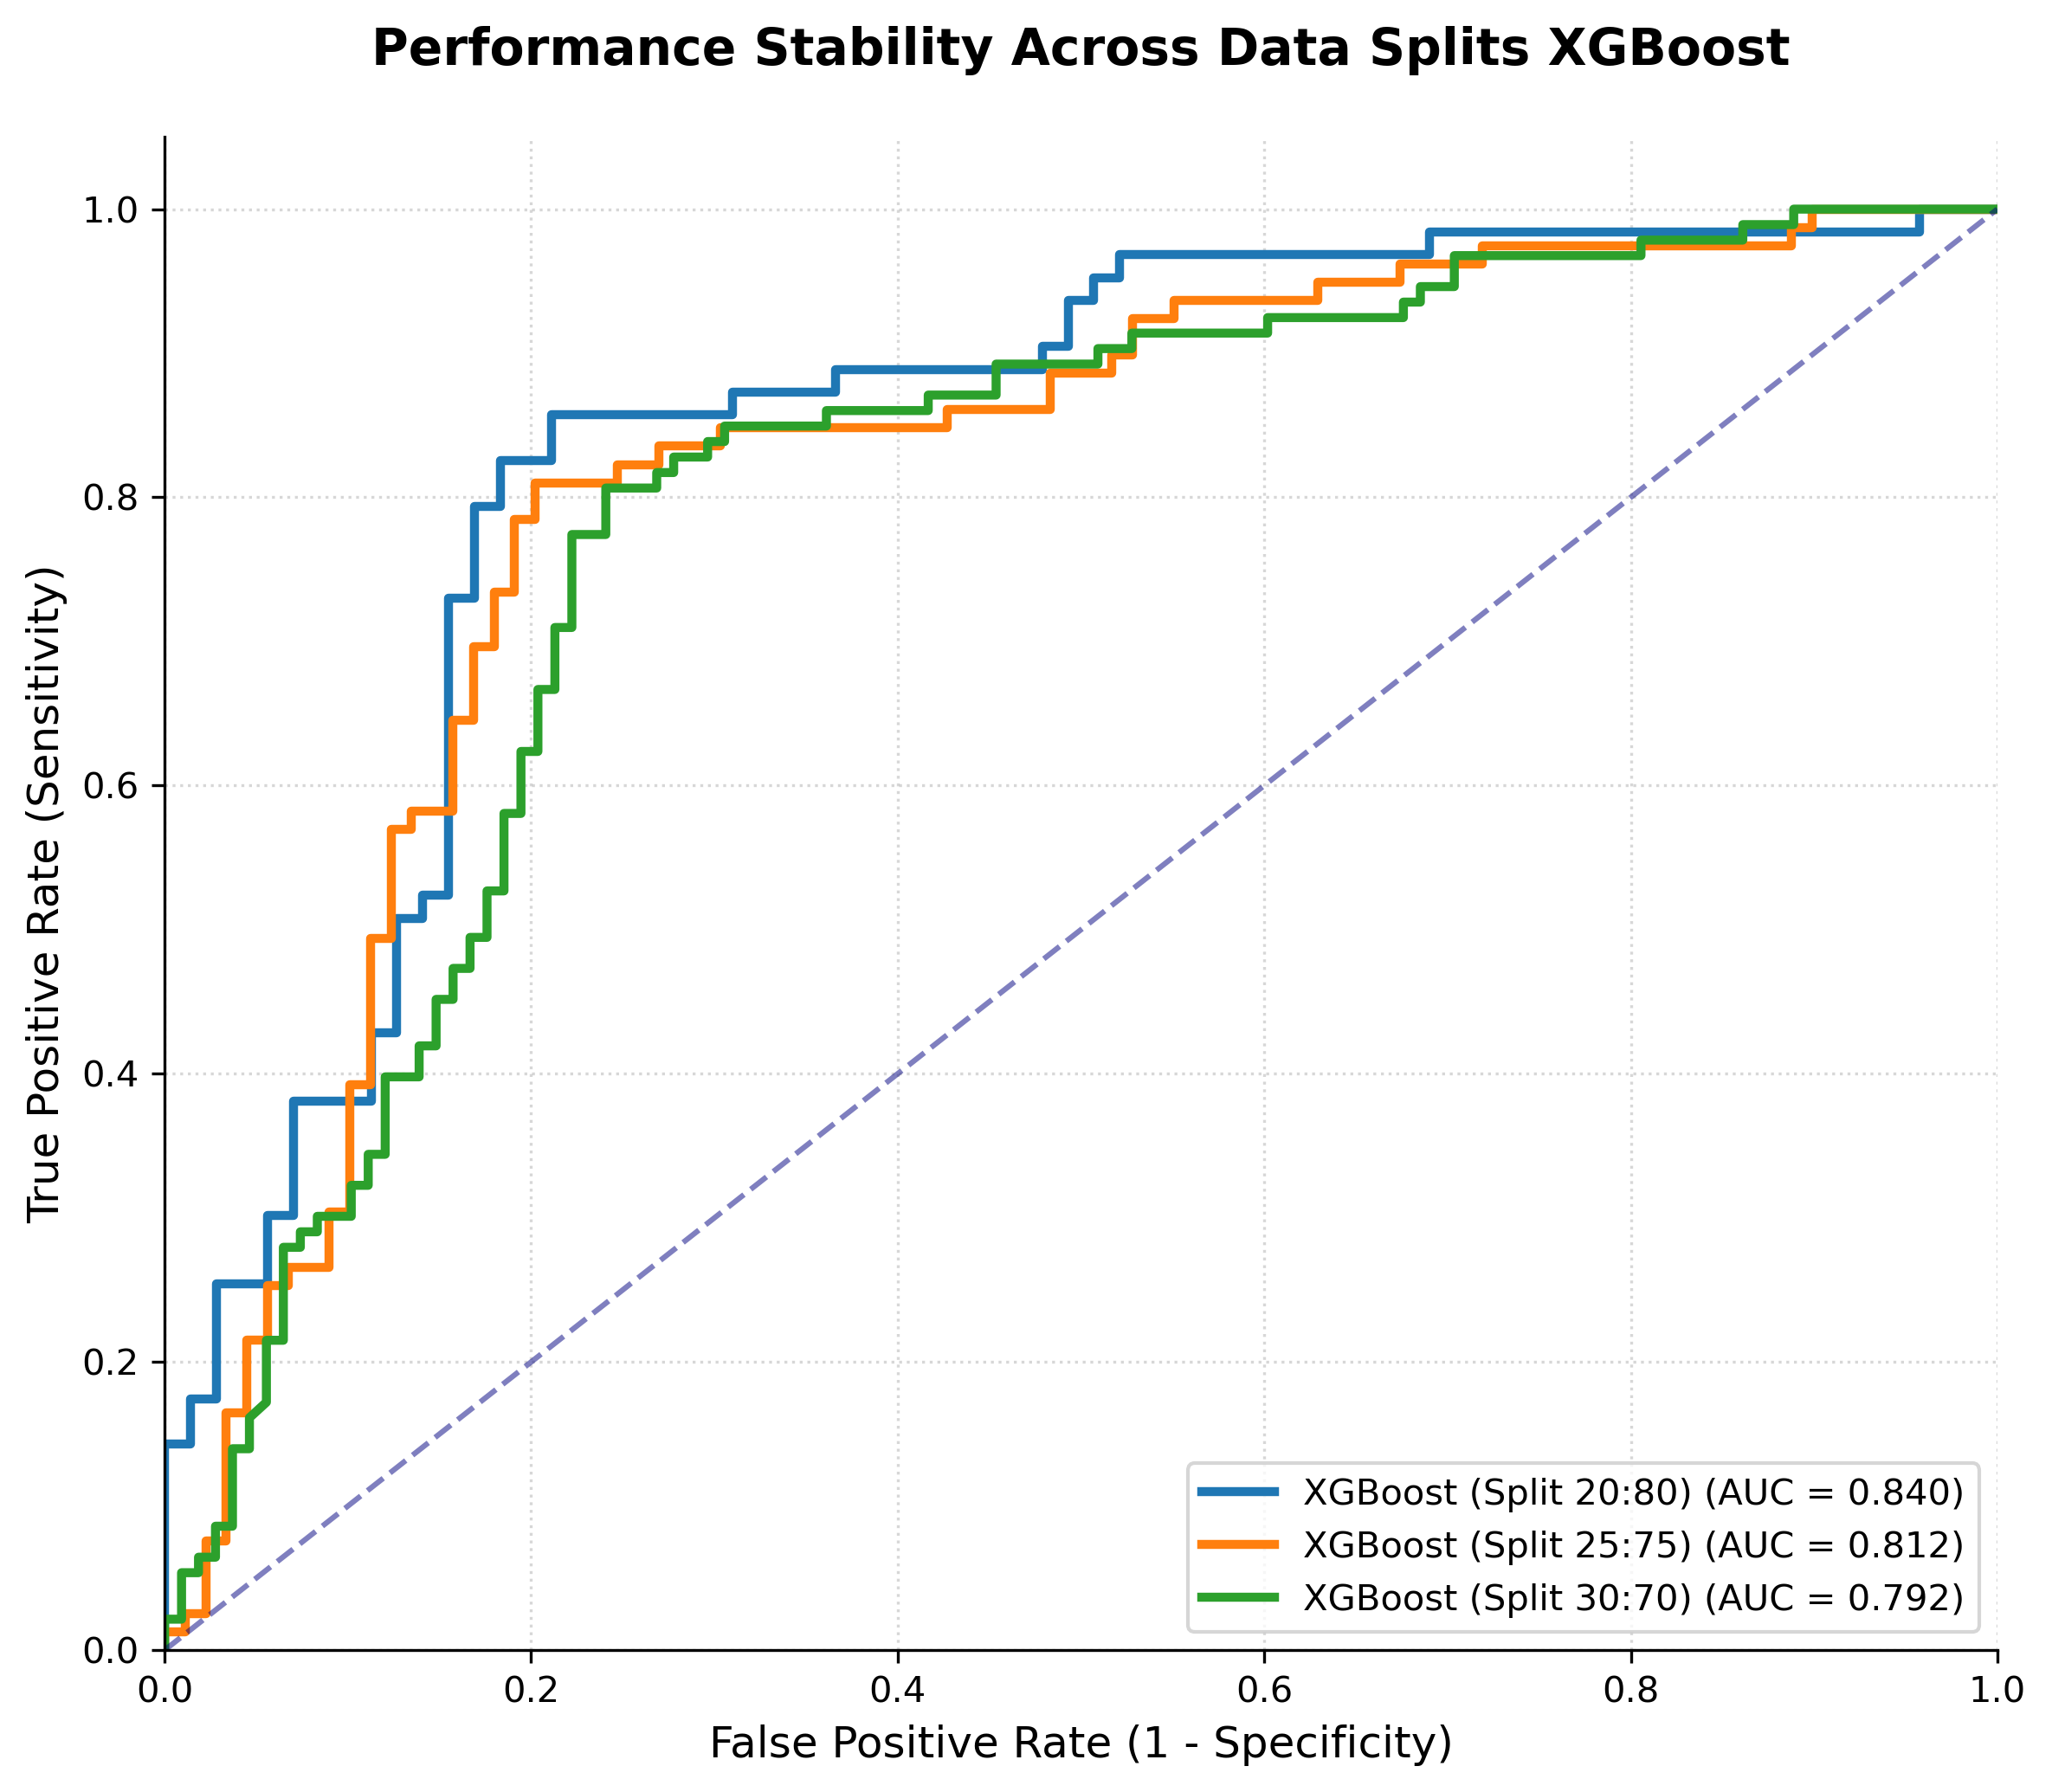

In [21]:
my_models = {
    'XGBoost (Split 20:80)': (xgb_20, X_test_20, y_test_20),
    'XGBoost (Split 25:75)': (xgb_25, X_test_25, y_test_25),
    'XGBoost (Split 30:70)': (xgb_30, X_test_30, y_test_30)
}

plot_multimodel_roc(my_models, title="Performance Stability Across Data Splits XGBoost", save_path="images/roc_auc_xgb.png")

In [17]:
# Save the best performing model
xgb_20.save_model('models/xgb_behavioural.json')

## Catboost

### Training

In [55]:
from catboost import CatBoostClassifier

def train_and_tune_cat(test_size):

    if test_size == 0.2:
        X_train, X_test, y_train = X_train_20, X_test_20, y_train_20
    elif test_size == 0.25:
        X_train, X_test, y_train = X_train_25, X_test_25, y_train_25
    else:
        X_train, X_test, y_train = X_train_30, X_test_30, y_train_30
        
    train_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    cat_model = CatBoostClassifier(
        loss_function='Logloss',
        random_seed=42,
        logging_level='Silent',
        thread_count=-1
    )
    
    param_grid = {
        'iterations': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [4, 6, 8],
        'l2_leaf_reg': [1, 3, 5, 7],
        'border_count': [32, 64, 128]
    }
    
    grid_search = GridSearchCV(
        estimator=cat_model,
        param_grid=param_grid,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train, sample_weight=train_sample_weights)
    
    print(f"===CATBOOST TUNING RESULT FOR SPLIT {test_size*100}:{(1-test_size) * 100}===")
    print(f"Best Parameters: {grid_search.best_params_}\n")

    return grid_search.best_estimator_, grid_search.best_score_, grid_search.cv_results_['std_test_score'][grid_search.best_index_]

cat_20, mean_score_cat_20, std_score_cat_20 = train_and_tune_cat(test_size=0.2)
cat_25, mean_score_cat_25, std_score_cat_25 = train_and_tune_cat(test_size=0.25)
cat_30, mean_score_cat_30, std_score_cat_30 = train_and_tune_cat(test_size=0.30)

===CATBOOST TUNING RESULT FOR SPLIT 20.0:80.0===
Best Parameters: {'border_count': 64, 'depth': 6, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}

===CATBOOST TUNING RESULT FOR SPLIT 25.0:75.0===
Best Parameters: {'border_count': 32, 'depth': 4, 'iterations': 500, 'l2_leaf_reg': 7, 'learning_rate': 0.05}

===CATBOOST TUNING RESULT FOR SPLIT 30.0:70.0===
Best Parameters: {'border_count': 64, 'depth': 4, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.05}



### Confusion Matrix and Classification Report

F1-Score: 0.77 (+/- 0.03)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.70      0.77        71
           1       0.72      0.86      0.78        63

    accuracy                           0.78       134
   macro avg       0.78      0.78      0.78       134
weighted avg       0.79      0.78      0.78       134



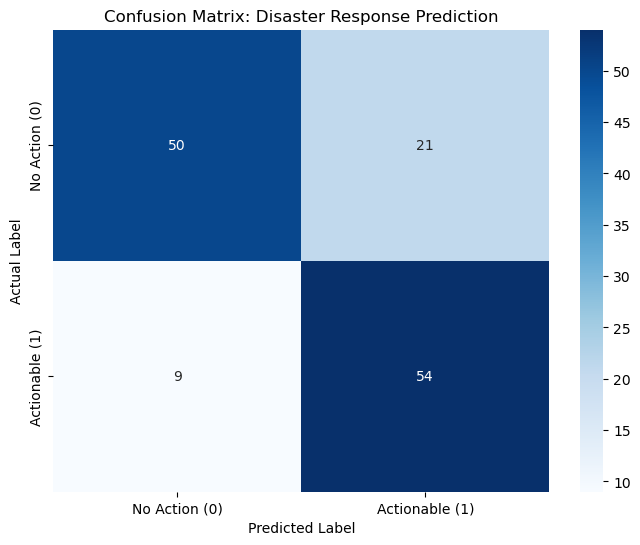

In [56]:
# Evaluate the 20 split
evaluate_model(cat_20, test_size=0.2, mean_score=mean_score_cat_20, std_score=std_score_cat_20)

F1-Score: 0.79 (+/- 0.03)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.72      0.77        89
           1       0.73      0.84      0.78        79

    accuracy                           0.77       168
   macro avg       0.78      0.78      0.77       168
weighted avg       0.78      0.77      0.77       168



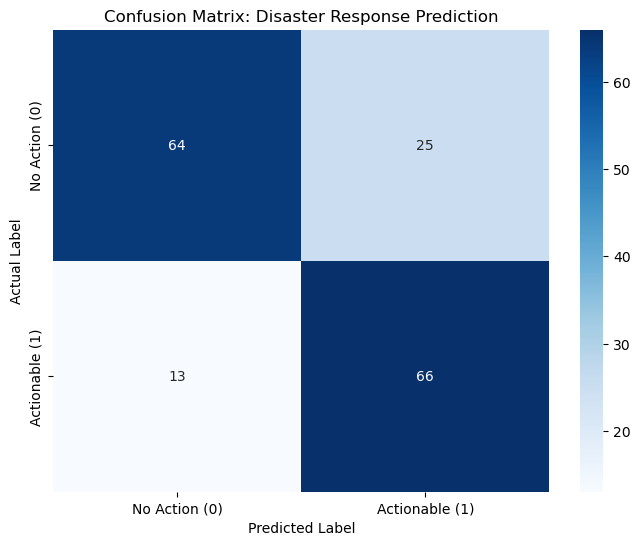

In [57]:
# Evaluate the 25 split
evaluate_model(cat_25, test_size=0.25, mean_score=mean_score_cat_25, std_score=std_score_cat_25)

F1-Score: 0.78 (+/- 0.02)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.67      0.75       108
           1       0.69      0.86      0.77        93

    accuracy                           0.76       201
   macro avg       0.77      0.76      0.76       201
weighted avg       0.77      0.76      0.76       201



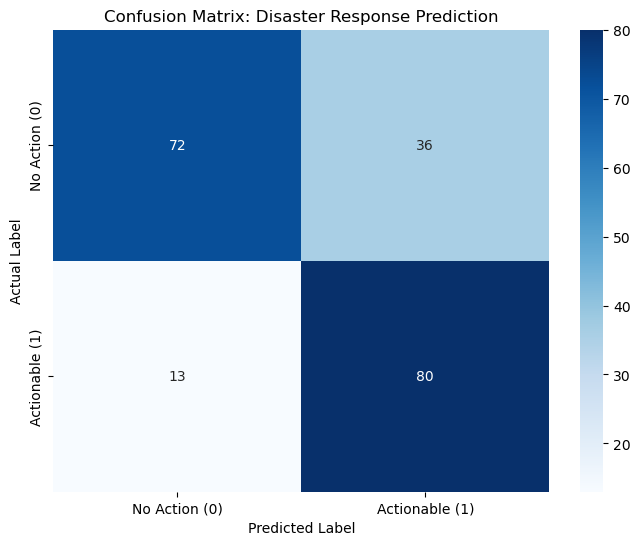

In [58]:
# Evaluate the 30 split
evaluate_model(cat_30, test_size=0.3, mean_score=mean_score_cat_30, std_score=std_score_cat_30)

### ROC-AUC Curve across splits

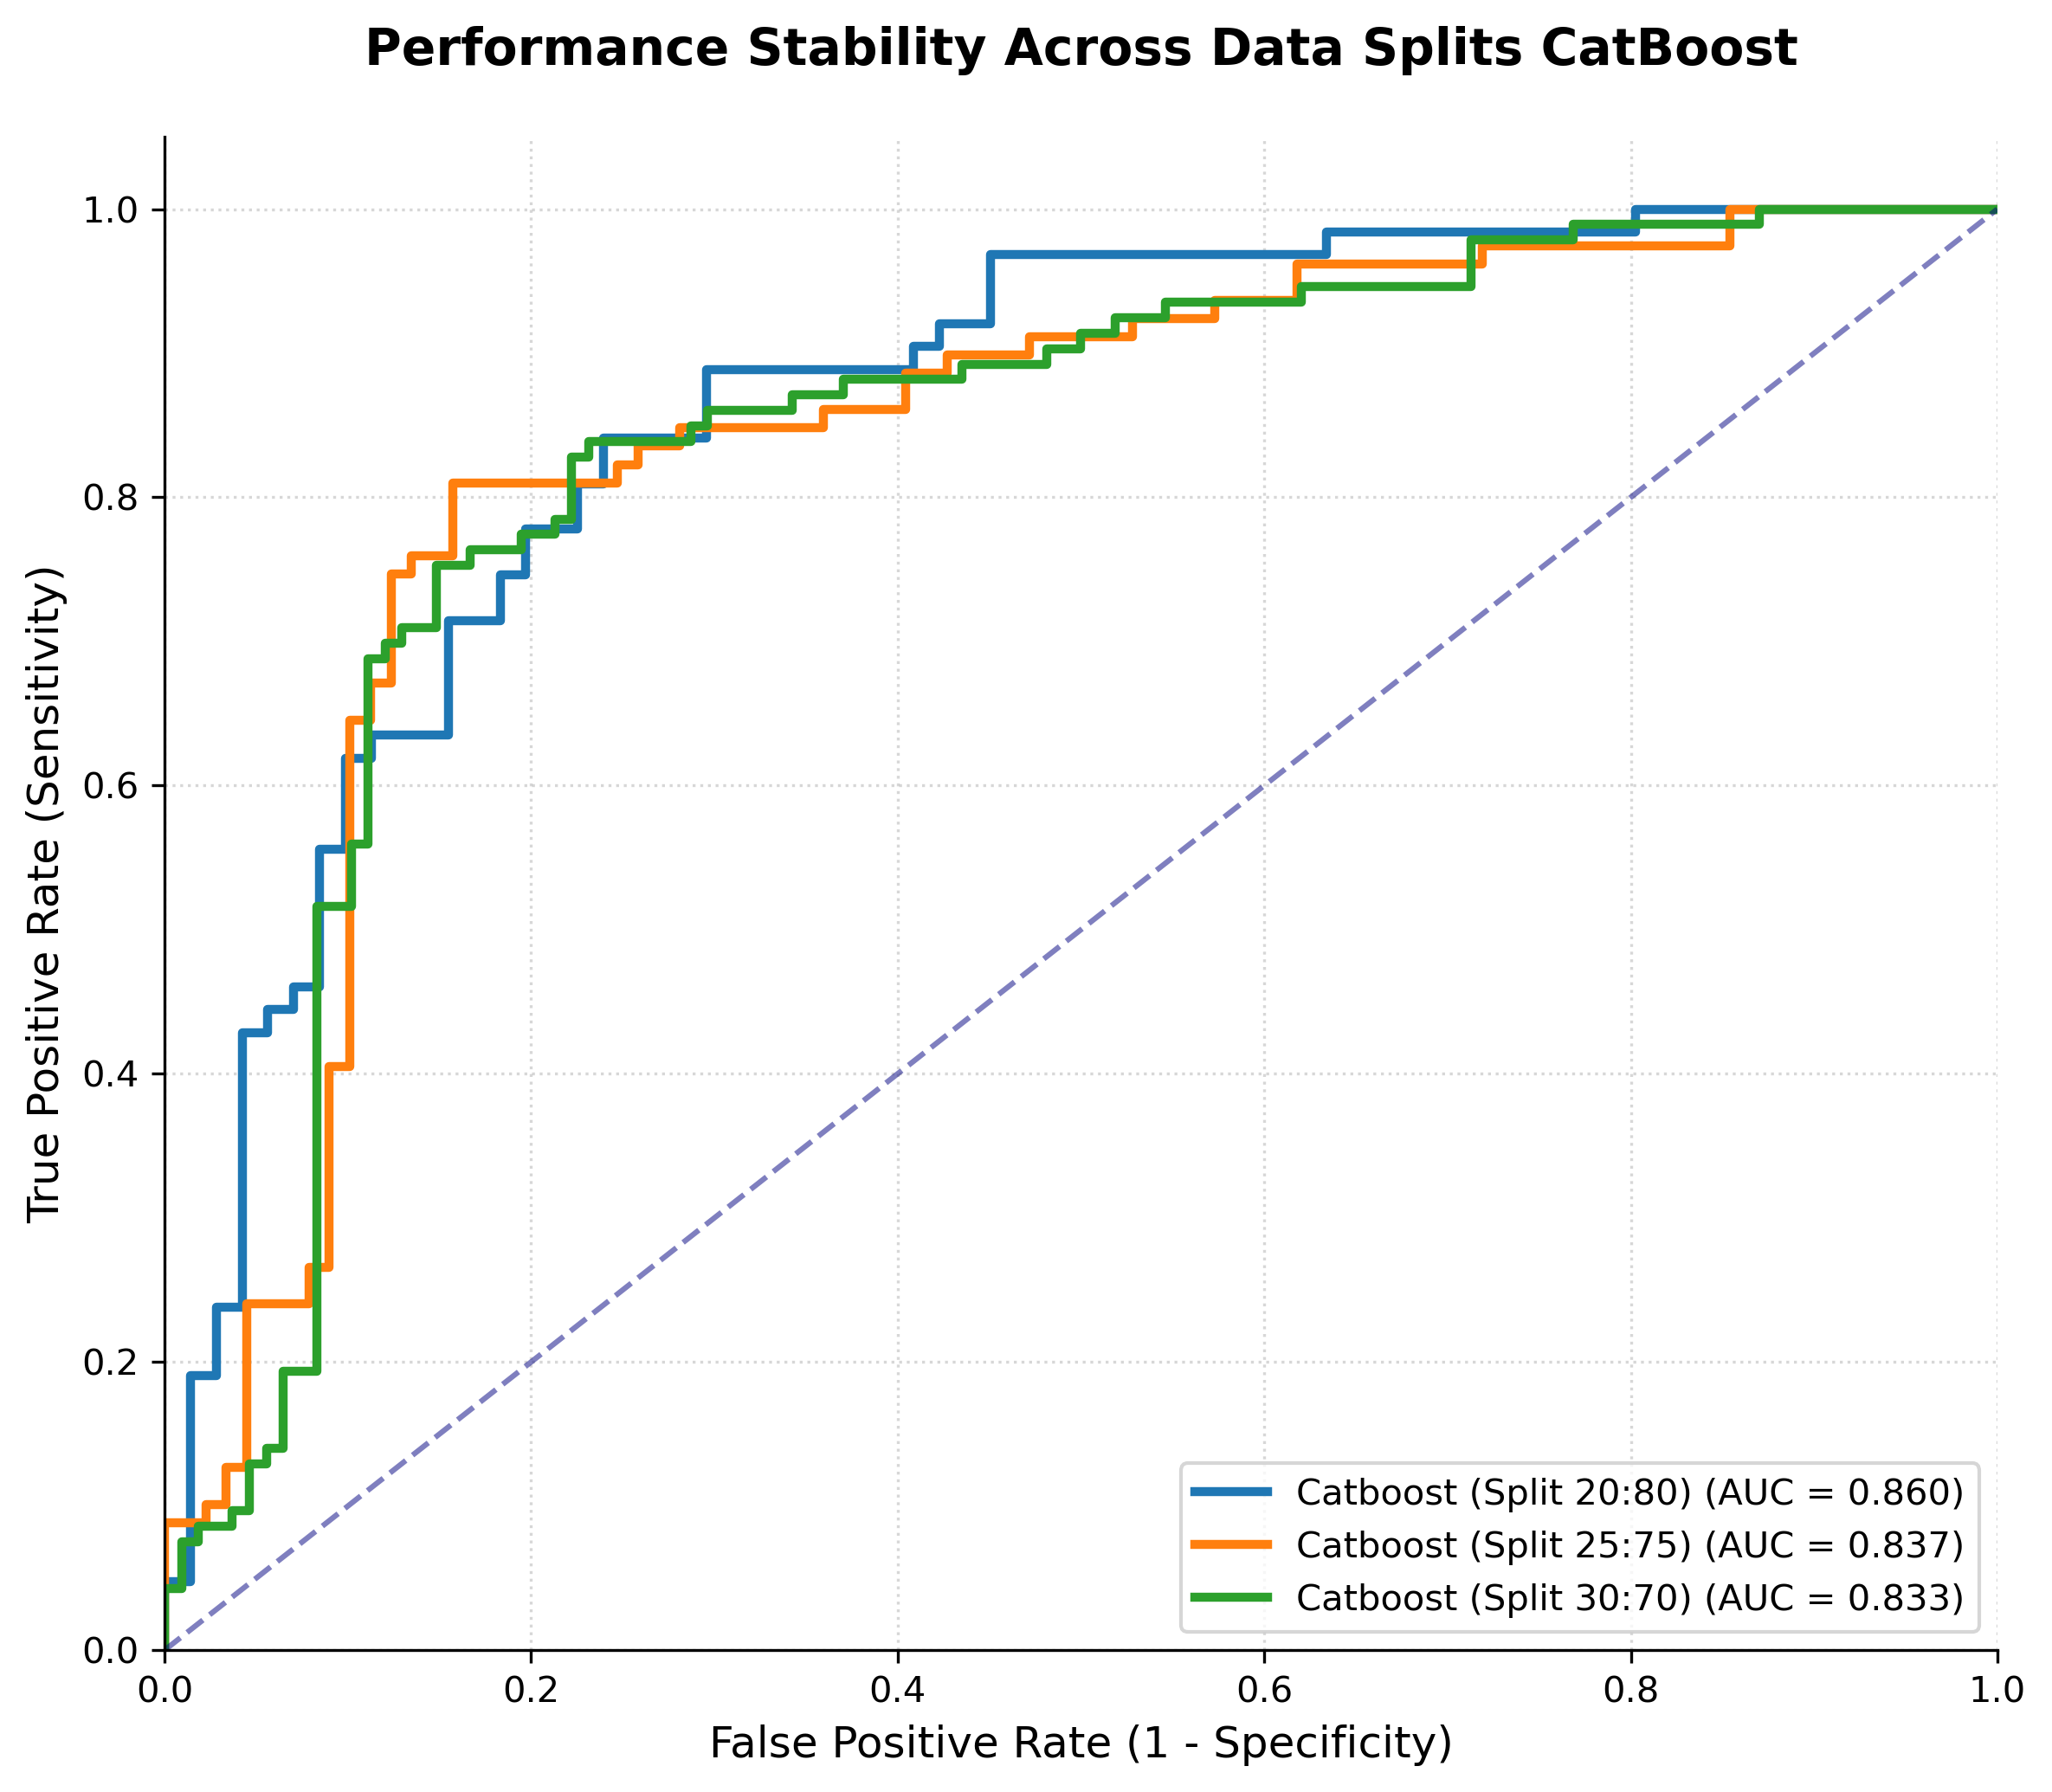

In [12]:
my_models = {
    'Catboost (Split 20:80)': (cat_20, X_test_20, y_test_20),
    'Catboost (Split 25:75)': (cat_25, X_test_25, y_test_25),
    'Catboost (Split 30:70)': (cat_30, X_test_30, y_test_30)
}

plot_multimodel_roc(my_models, title="Performance Stability Across Data Splits CatBoost", save_path="images/roc_auc_cat.png")

## LightGBM

### Training

In [51]:
from lightgbm import LGBMClassifier

def train_and_tune_lgb(test_size): 
    
    if test_size == 0.2:
        X_train, X_test, y_train = X_train_20, X_test_20, y_train_20
    elif test_size == 0.25:
        X_train, X_test, y_train = X_train_25, X_test_25, y_train_25
    else:
        X_train, X_test, y_train = X_train_30, X_test_30, y_train_30
        
    train_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
    
    param_grid_lgb = {
        'max_depth': [3, 4, 6],
        'num_leaves': [15, 31, 63],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 300],
        'min_child_samples': [10, 20, 30]
    }
    
    grid_lgb = GridSearchCV(
        estimator=LGBMClassifier(objective='binary', random_state=42, verbosity=-1),
        param_grid=param_grid_lgb,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )
    
    grid_lgb.fit(X_train, y_train, sample_weight=train_sample_weights)

    print(f"===LGB TUNING RESULT FOR SPLIT {test_size*100}:{(1-test_size) * 100}===")
    print(f"Best Parameters: {grid_lgb.best_params_}\n")
    
    return grid_lgb.best_estimator_, grid_lgb.best_score_, grid_lgb.cv_results_['std_test_score'][grid_lgb.best_index_]

lgb_20, mean_score_lgb_20, std_score_lgb_20 = train_and_tune_lgb(test_size=0.2)
lgb_25, mean_score_lgb_25, std_score_lgb_25 = train_and_tune_lgb(test_size=0.25)
lgb_30, mean_score_lgb_30, std_score_lgb_30 = train_and_tune_lgb(test_size=0.30)

===LGB TUNING RESULT FOR SPLIT 20.0:80.0===
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 15}

===LGB TUNING RESULT FOR SPLIT 25.0:75.0===
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 15}

===LGB TUNING RESULT FOR SPLIT 30.0:70.0===
Best Parameters: {'learning_rate': 0.01, 'max_depth': 6, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 31}



### Confusion Matrix and Classification Report

F1-Score: 0.76 (+/- 0.02)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.69      0.75        71
           1       0.71      0.84      0.77        63

    accuracy                           0.76       134
   macro avg       0.77      0.77      0.76       134
weighted avg       0.77      0.76      0.76       134



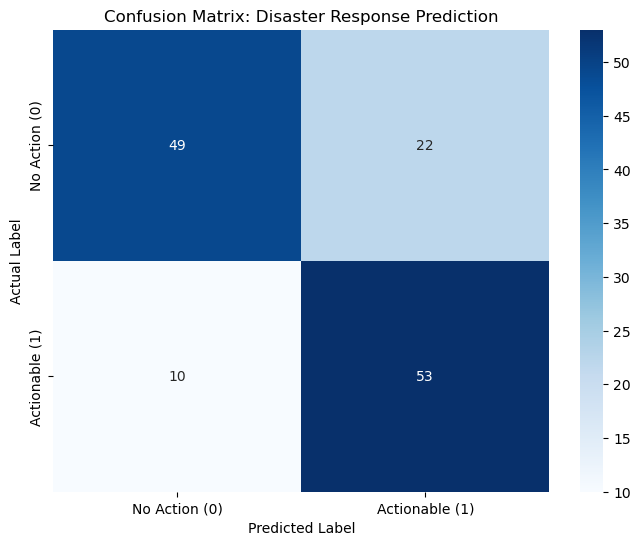

In [52]:
# Evaluate the 20 split
evaluate_model(lgb_20, test_size=0.2, mean_score=mean_score_lgb_20, std_score=std_score_lgb_20)

F1-Score: 0.76 (+/- 0.03)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        89
           1       0.74      0.80      0.77        79

    accuracy                           0.77       168
   macro avg       0.77      0.78      0.77       168
weighted avg       0.78      0.77      0.77       168



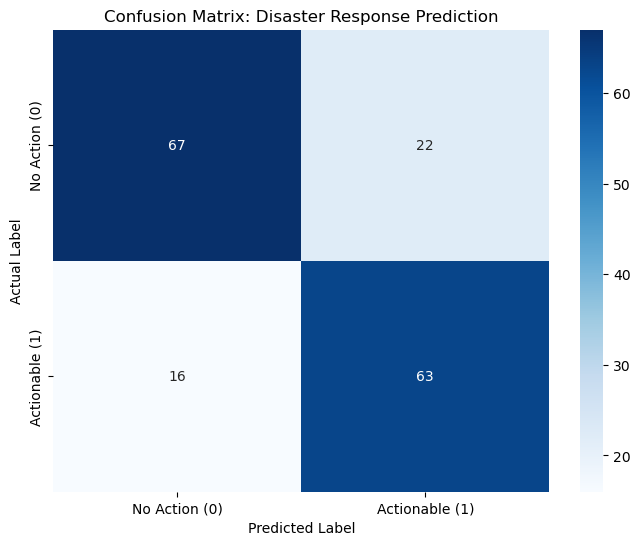

In [53]:
# Evaluate the 25 split
evaluate_model(lgb_25, test_size=0.25, mean_score=mean_score_lgb_25, std_score=std_score_lgb_25)

F1-Score: 0.75 (+/- 0.04)

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.68      0.76       108
           1       0.70      0.88      0.78        93

    accuracy                           0.77       201
   macro avg       0.78      0.78      0.77       201
weighted avg       0.79      0.77      0.77       201



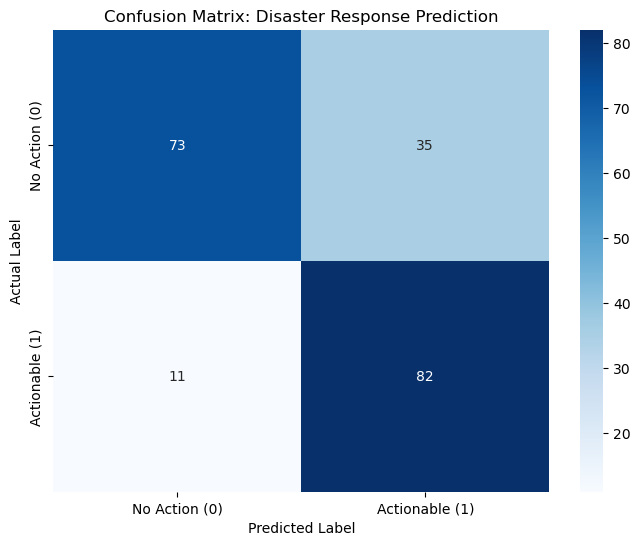

In [54]:
# Evaluate the 30 split
evaluate_model(lgb_30, test_size=0.3, mean_score=mean_score_lgb_30, std_score=std_score_lgb_30)

### ROC-AUC Curve across splits

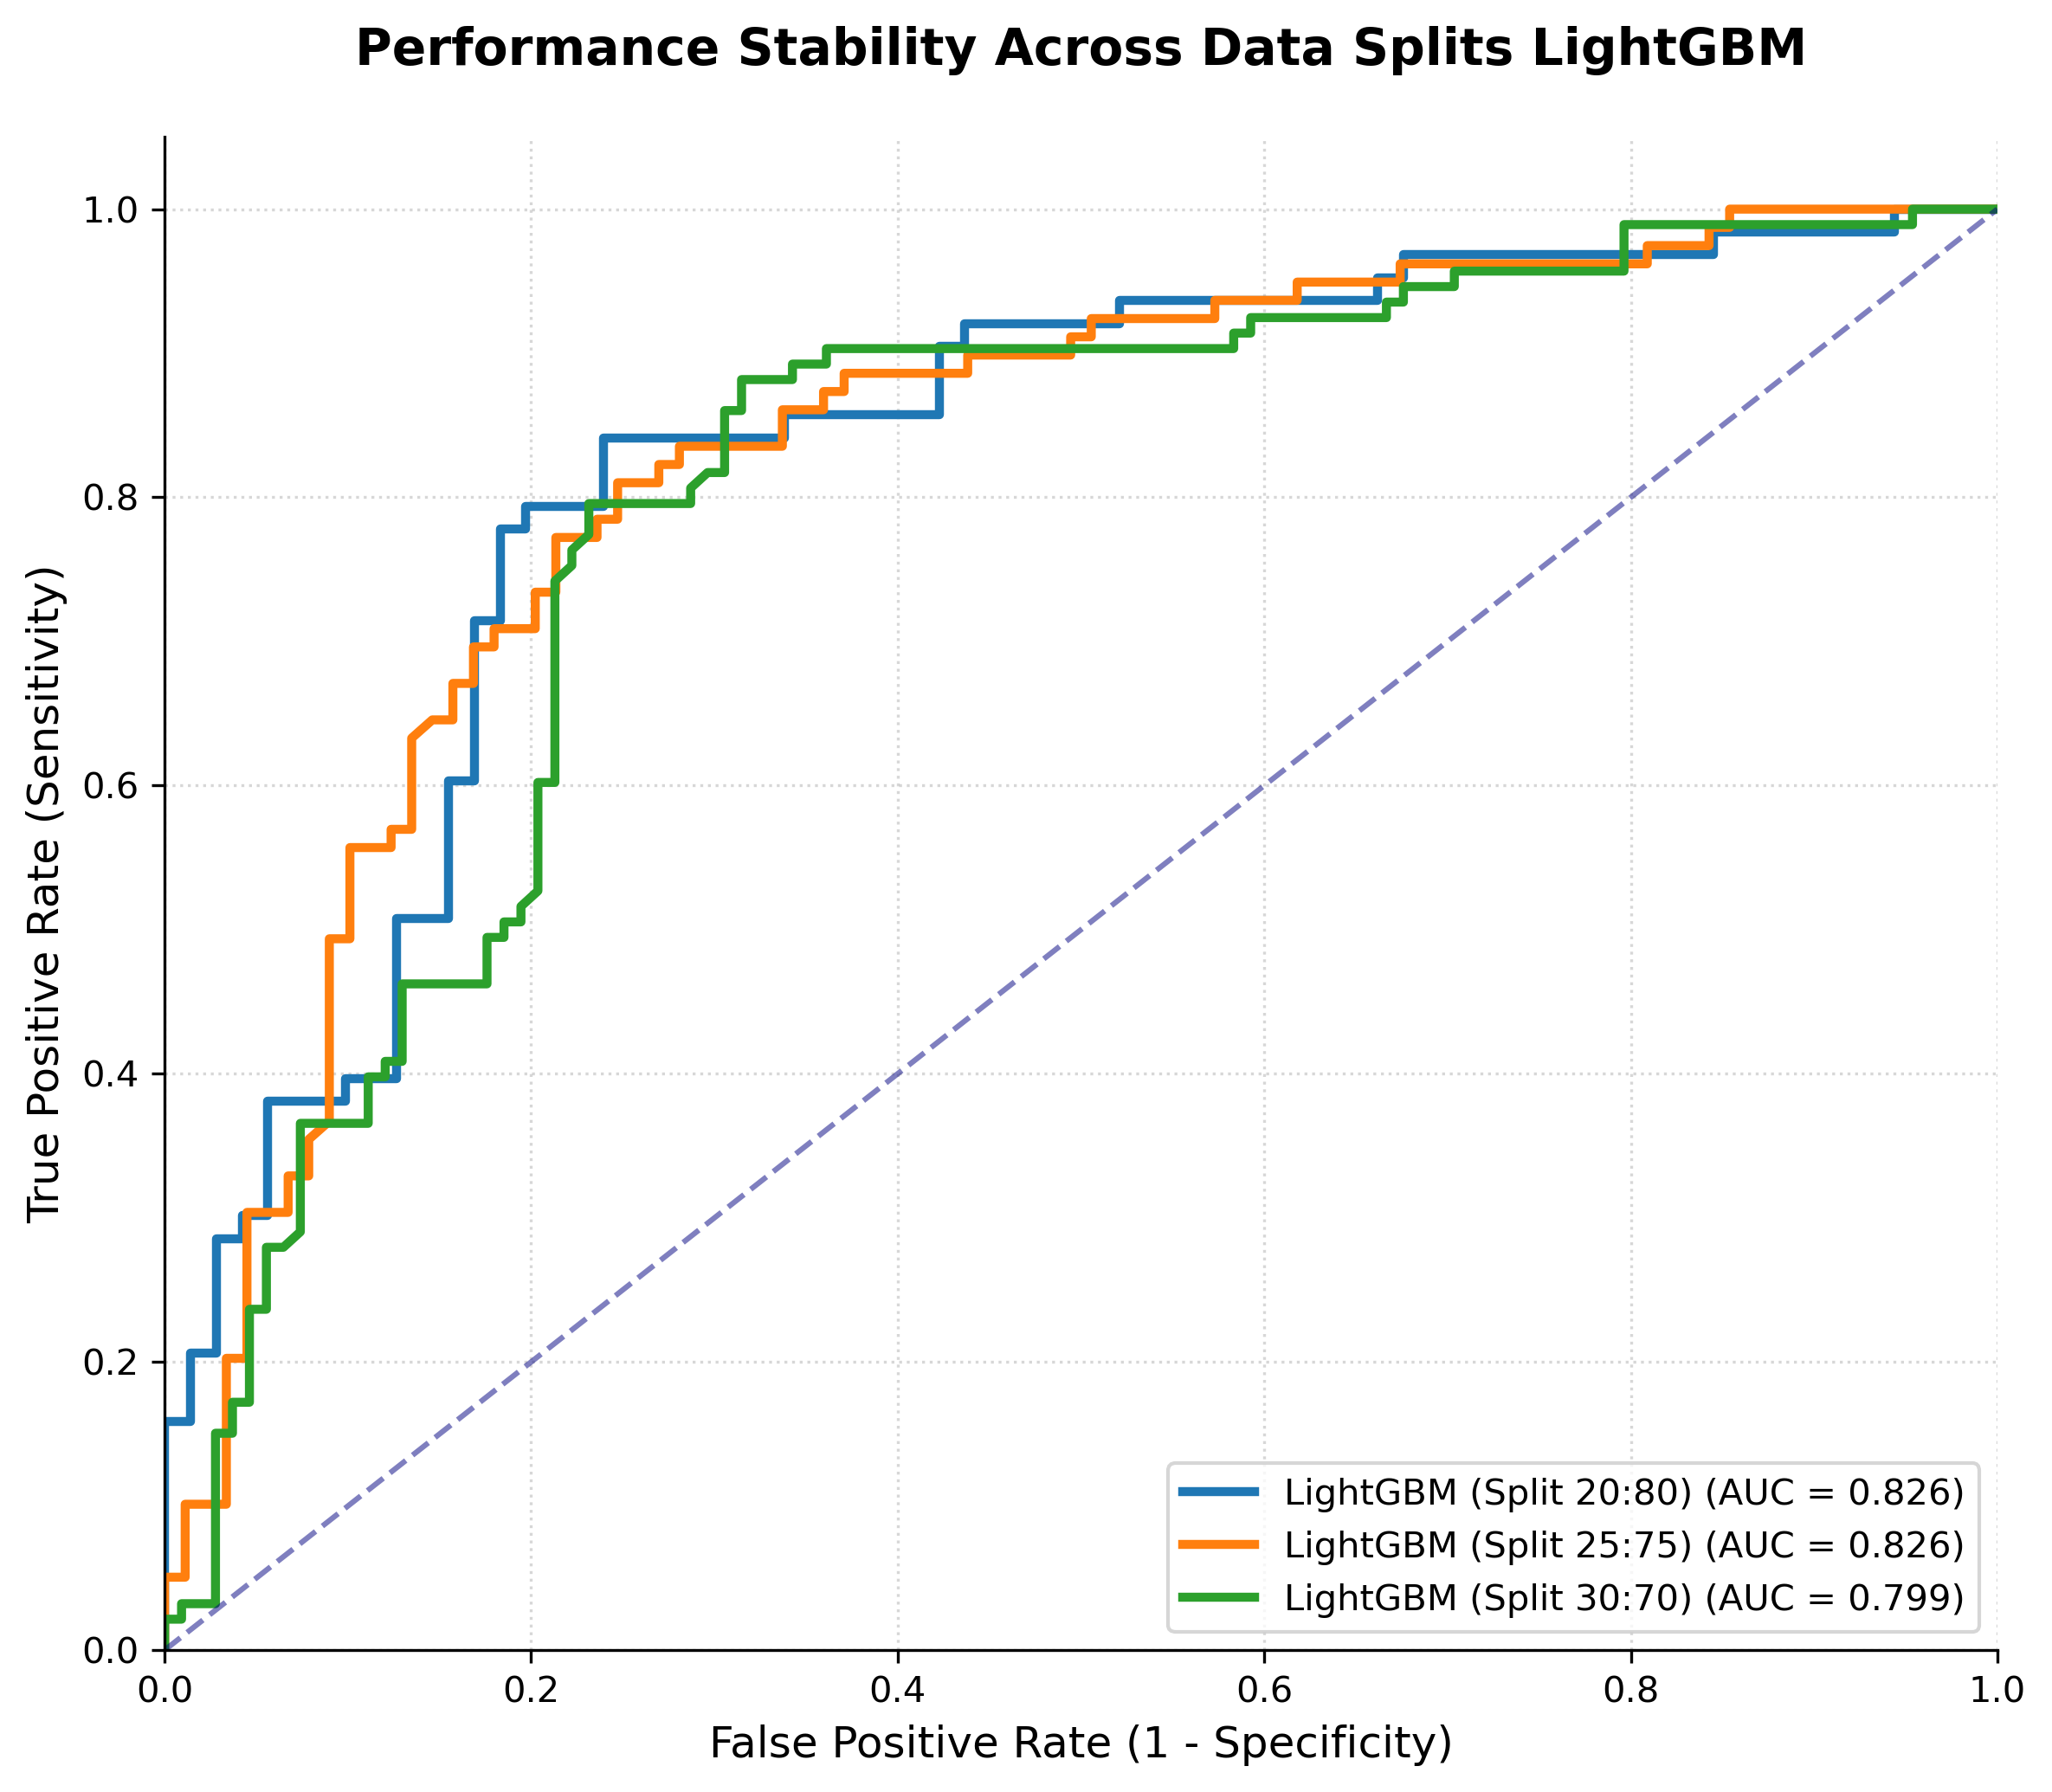

In [18]:
my_models = {
    'LightGBM (Split 20:80)': (lgb_20, X_test_20, y_test_20),
    'LightGBM (Split 25:75)': (lgb_25, X_test_25, y_test_25),
    'LightGBM (Split 30:70)': (lgb_30, X_test_30, y_test_30)
}

plot_multimodel_roc(my_models, title="Performance Stability Across Data Splits LightGBM", save_path="images/roc_auc_lgb.png")

## Summary

**Performance Comparison Table**

| Algorithm | Split Ratio | CV F1-Macro (Mean ± Std) | Accuracy | Precision (Class 0) | Recall (Class 0) | ROC-AUC |
|----------|------------|--------------------------|----------|---------------------|------------------|---------|
| XGBoost  | 20:80      | 0.76±0.004               | 0.81     | 0.86                | 0.77             | 0.840   |
| XGBoost  | 25:75      | 0.76±0.02               | 0.77     | 0.82                | 0.73             | 0.812   |
| XGBoost  | 30:70      | 0.75±0.04               | 0.77     | 0.84                | 0.70             | 0.792   |
| CatBoost | 20:80      | 0.77±0.03               | 0.78     | 0.85                | 0.70             | 0.860   |
| CatBoost | 25:75      | 0.79±0.03               | 0.77     | 0.83                | 0.72             | 0.837   |
| CatBoost | 30:70      | 0.78±0.02               | 0.76     | 0.85                | 0.67             | 0.833   |
| LightGBM | 20:80      | 0.76±0.02               | 0.76     | 0.83                | 0.69             | 0.826   |
| LightGBM | 25:75      | 0.76±0.03               | 0.77     | 0.81                | 0.75             | 0.826   |
| LightGBM | 30:70      | 0.75±0.04               | 0.77     | 0.87                | 0.68             | 0.799   |

The experimental evaluation confirms that XGBoost at a **20:80 split** remains the superior choice for high-stakes risk prediction, achieving a peak **Recall of 0.77** and **Precision of 0.86** for unsafe behaviors. The integration of **5-fold Cross-Validation** provides rigorous evidence of model reliability, with the **XGBoost 20:80** configuration showing remarkable consistency indicated by a **Standard Deviation of 0.004** during internal validation. While **CatBoost** demonstrates the highest discriminative power with a peak **ROC-AUC of 0.860** and the most stable performance across varying data volumes, XGBoost's better alignment with Class 0 detection is more critical for disaster intervention. These findings signify a robust synergy between Local Indigenous Knowledge (LIK) and demographic indicators, ensuring that the predictive rules are statistically significant and resilient to variations in the training sample.